# TensorFlow

Sequential API tutorial on the MNIST dataset.

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [2]:
tf.__version__

'2.16.2'

In [49]:
LEARNING_RATE = 0.001
NUM_EPOCHS = 25
BATCH_SIZE = 32

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

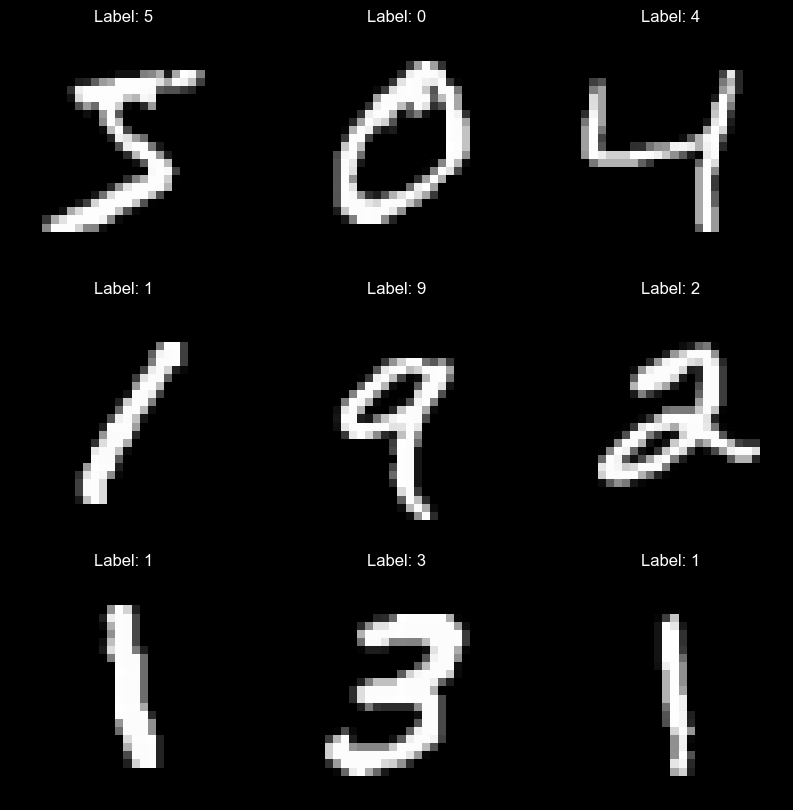

In [5]:
# display examples from the training set 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    for j in range(3):
        axes[i, j].imshow(x_train[i * 3 + j], cmap='gray')
        axes[i, j].set_title(f'Label: {y_train[i * 3 + j]}')
        axes[i, j].axis('off')
plt.show()

In [38]:
# create a model using the Sequential API
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28), name="input"),
    keras.layers.Flatten(name="flatten"),
    keras.layers.Dense(64, activation='relu', name="hidden-1"),
    keras.layers.Dense(10, activation='softmax', name="output")
])

In [39]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden-1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# compile the model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [41]:
# early stopping callback
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [42]:
# train the model
history = model.fit(x_train, y_train,
                    epochs=NUM_EPOCHS,
                    validation_split=0.15,
                    verbose=2,
                    callbacks=[early_stopping]
)

Epoch 1/25
1594/1594 - 8s - 5ms/step - accuracy: 0.8258 - loss: 15.3980 - val_accuracy: 0.8638 - val_loss: 11.5995
Epoch 2/25
1594/1594 - 7s - 4ms/step - accuracy: 0.8630 - loss: 12.8582 - val_accuracy: 0.8726 - val_loss: 13.4668
Epoch 3/25
1594/1594 - 8s - 5ms/step - accuracy: 0.8661 - loss: 14.5511 - val_accuracy: 0.8944 - val_loss: 12.0723
Epoch 4/25
1594/1594 - 8s - 5ms/step - accuracy: 0.8683 - loss: 16.0750 - val_accuracy: 0.8920 - val_loss: 12.7954


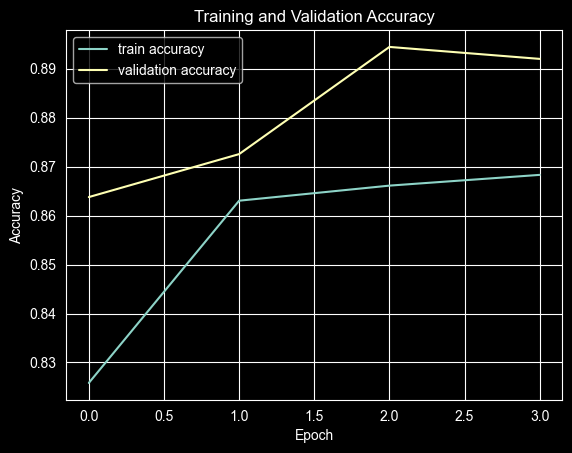

In [43]:
# plot training and validation accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [44]:
# test the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Test accuracy: {test_acc:.4f}')

313/313 - 1s - 3ms/step - accuracy: 0.8645 - loss: 12.7664
Test accuracy: 0.8645


In [45]:
# do the same thing but with a normalized dataset
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [46]:
# retrain the model with normalized data
history = model.fit(x_train, y_train,
                    batch_size=BATCH_SIZE,
                    epochs=NUM_EPOCHS,
                    validation_split=0.15,
                    verbose=2,
                    callbacks=[early_stopping]
)

Epoch 1/25
1594/1594 - 9s - 5ms/step - accuracy: 0.8357 - loss: 1.0084 - val_accuracy: 0.8799 - val_loss: 0.7744
Epoch 2/25
1594/1594 - 8s - 5ms/step - accuracy: 0.8712 - loss: 0.6635 - val_accuracy: 0.8952 - val_loss: 0.5122
Epoch 3/25
1594/1594 - 8s - 5ms/step - accuracy: 0.8849 - loss: 0.4812 - val_accuracy: 0.9050 - val_loss: 0.3848
Epoch 4/25
1594/1594 - 8s - 5ms/step - accuracy: 0.8984 - loss: 0.3848 - val_accuracy: 0.9164 - val_loss: 0.3169
Epoch 5/25
1594/1594 - 8s - 5ms/step - accuracy: 0.9084 - loss: 0.3316 - val_accuracy: 0.9182 - val_loss: 0.2862
Epoch 6/25
1594/1594 - 8s - 5ms/step - accuracy: 0.9142 - loss: 0.3046 - val_accuracy: 0.9258 - val_loss: 0.2638
Epoch 7/25
1594/1594 - 8s - 5ms/step - accuracy: 0.9173 - loss: 0.2933 - val_accuracy: 0.9252 - val_loss: 0.2614
Epoch 8/25
1594/1594 - 8s - 5ms/step - accuracy: 0.9167 - loss: 0.2930 - val_accuracy: 0.9246 - val_loss: 0.2670
Epoch 9/25
1594/1594 - 8s - 5ms/step - accuracy: 0.9170 - loss: 0.2969 - val_accuracy: 0.9246 - 

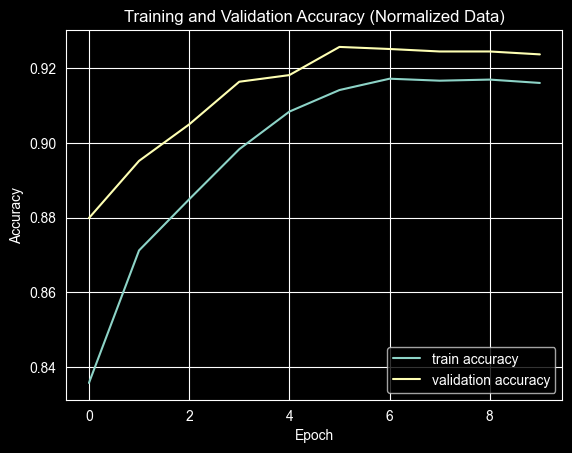

In [47]:
# plot training and validation accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy (Normalized Data)')
plt.show()

In [48]:
# test the model with normalized data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Test accuracy (normalized data): {test_acc:.4f}')

313/313 - 1s - 4ms/step - accuracy: 0.9190 - loss: 0.2843
Test accuracy (normalized data): 0.9190


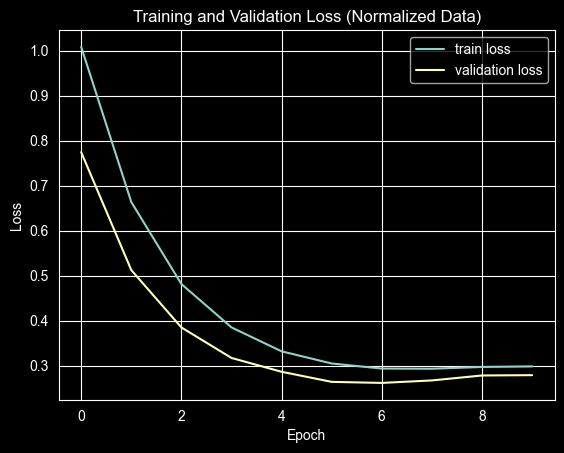

In [50]:
# plot the training and validation loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss (Normalized Data)')
plt.show()